In [1]:
#pip install kagglehub[pandas-datasets]

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Life Expectancy Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "kumarajarshi/life-expectancy-who",
  file_path,
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df.columns = df.columns.str.strip()

txt_cols = df.select_dtypes('object').columns
num_cols = df.select_dtypes('number').columns

c:\dev\data-science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\kevin\AppData\Local\Temp\ipykernel_17384\1037255051.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.00,263.00,62,0.01,71.28,65.00,1154,19.10,83,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,Afghanistan,2014,Developing,59.90,271.00,64,0.01,73.52,62.00,492,18.60,86,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,Afghanistan,2013,Developing,59.90,268.00,66,0.01,73.22,64.00,430,18.10,89,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,Afghanistan,2012,Developing,59.50,272.00,69,0.01,78.18,67.00,2787,17.60,93,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,Afghanistan,2011,Developing,59.20,275.00,71,0.01,7.10,68.00,3013,17.20,97,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

## Missing and duplicate values

In [5]:
df.isnull().sum()/df.shape[0] * 100

Country                            0.00
Year                               0.00
Status                             0.00
Life expectancy                    0.34
Adult Mortality                    0.34
infant deaths                      0.00
Alcohol                            6.60
percentage expenditure             0.00
Hepatitis B                       18.82
Measles                            0.00
BMI                                1.16
under-five deaths                  0.00
Polio                              0.65
Total expenditure                  7.69
Diphtheria                         0.65
HIV/AIDS                           0.00
GDP                               15.25
Population                        22.19
thinness  1-19 years               1.16
thinness 5-9 years                 1.16
Income composition of resources    5.68
Schooling                          5.55
dtype: float64

In [6]:
df.duplicated().sum()/df.shape[0] * 100

np.float64(0.0)

In [7]:
for col in txt_cols:  # garbage values 
    print(df[col].value_counts())
    print('#'*20)

Country
Afghanistan                                             16
Albania                                                 16
Algeria                                                 16
Angola                                                  16
Antigua and Barbuda                                     16
Argentina                                               16
Armenia                                                 16
Australia                                               16
Austria                                                 16
Azerbaijan                                              16
Bahamas                                                 16
Bahrain                                                 16
Bangladesh                                              16
Barbados                                                16
Belarus                                                 16
Belgium                                                 16
Belize                                          

## Eda

In [8]:
from math import ceil

def plot_grid(df, cols, plot_func, n_cols=3, figsize_unit=(5, 4), **kwargs):
    """
    Gera uma grade dinâmica de gráficos.
    
    Args:
        df: DataFrame original.
        cols: Lista de colunas para iterar.
        plot_func: A função do seaborn/matplotlib (ex: sns.boxplot).
        n_cols: Quantidade de colunas na grade.
        figsize_unit: (largura, altura) de CADA subgráfico.
        **kwargs: Argumentos extras para a função de plot (ex: y='target', kde=True).
    """
    n_plots = len(cols)
    n_rows = ceil(n_plots / n_cols)
    
    # Criar a moldura dinâmica
    fig, axes = plt.subplots(
        n_rows, 
        n_cols, 
        figsize=(n_cols * figsize_unit[0], n_rows * figsize_unit[1])
    )
    
    # Garantir que axes seja uma lista mesmo se houver apenas 1 gráfico
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, col in enumerate(cols):
        # Chamada dinâmica da função de plot
        # Passamos o eixo atual (ax=axes[i]) e os argumentos extras (**kwargs)
        plot_func(data=df, x=col, ax=axes[i], **kwargs)
        
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel(col)
        
    # Remover eixos vazios
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.00,2007.52,4.61,2000.00,2004.00,2008.00,2012.00,2015.00
Life expectancy,2928.00,69.22,9.52,36.30,63.10,72.10,75.70,89.00
Adult Mortality,2928.00,164.80,124.29,1.00,74.00,144.00,228.00,723.00
infant deaths,2938.00,30.30,117.93,0.00,0.00,3.00,22.00,1800.00
Alcohol,2744.00,4.60,4.05,0.01,0.88,3.75,7.70,17.87
percentage expenditure,2938.00,738.25,1987.91,0.00,4.69,64.91,441.53,19479.91
Hepatitis B,2385.00,80.94,25.07,1.00,77.00,92.00,97.00,99.00
Measles,2938.00,2419.59,11467.27,0.00,0.00,17.00,360.25,212183.00
BMI,2904.00,38.32,20.04,1.00,19.30,43.50,56.20,87.30
under-five deaths,2938.00,42.04,160.45,0.00,0.00,4.00,28.00,2500.00


In [10]:
df[txt_cols].describe()

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


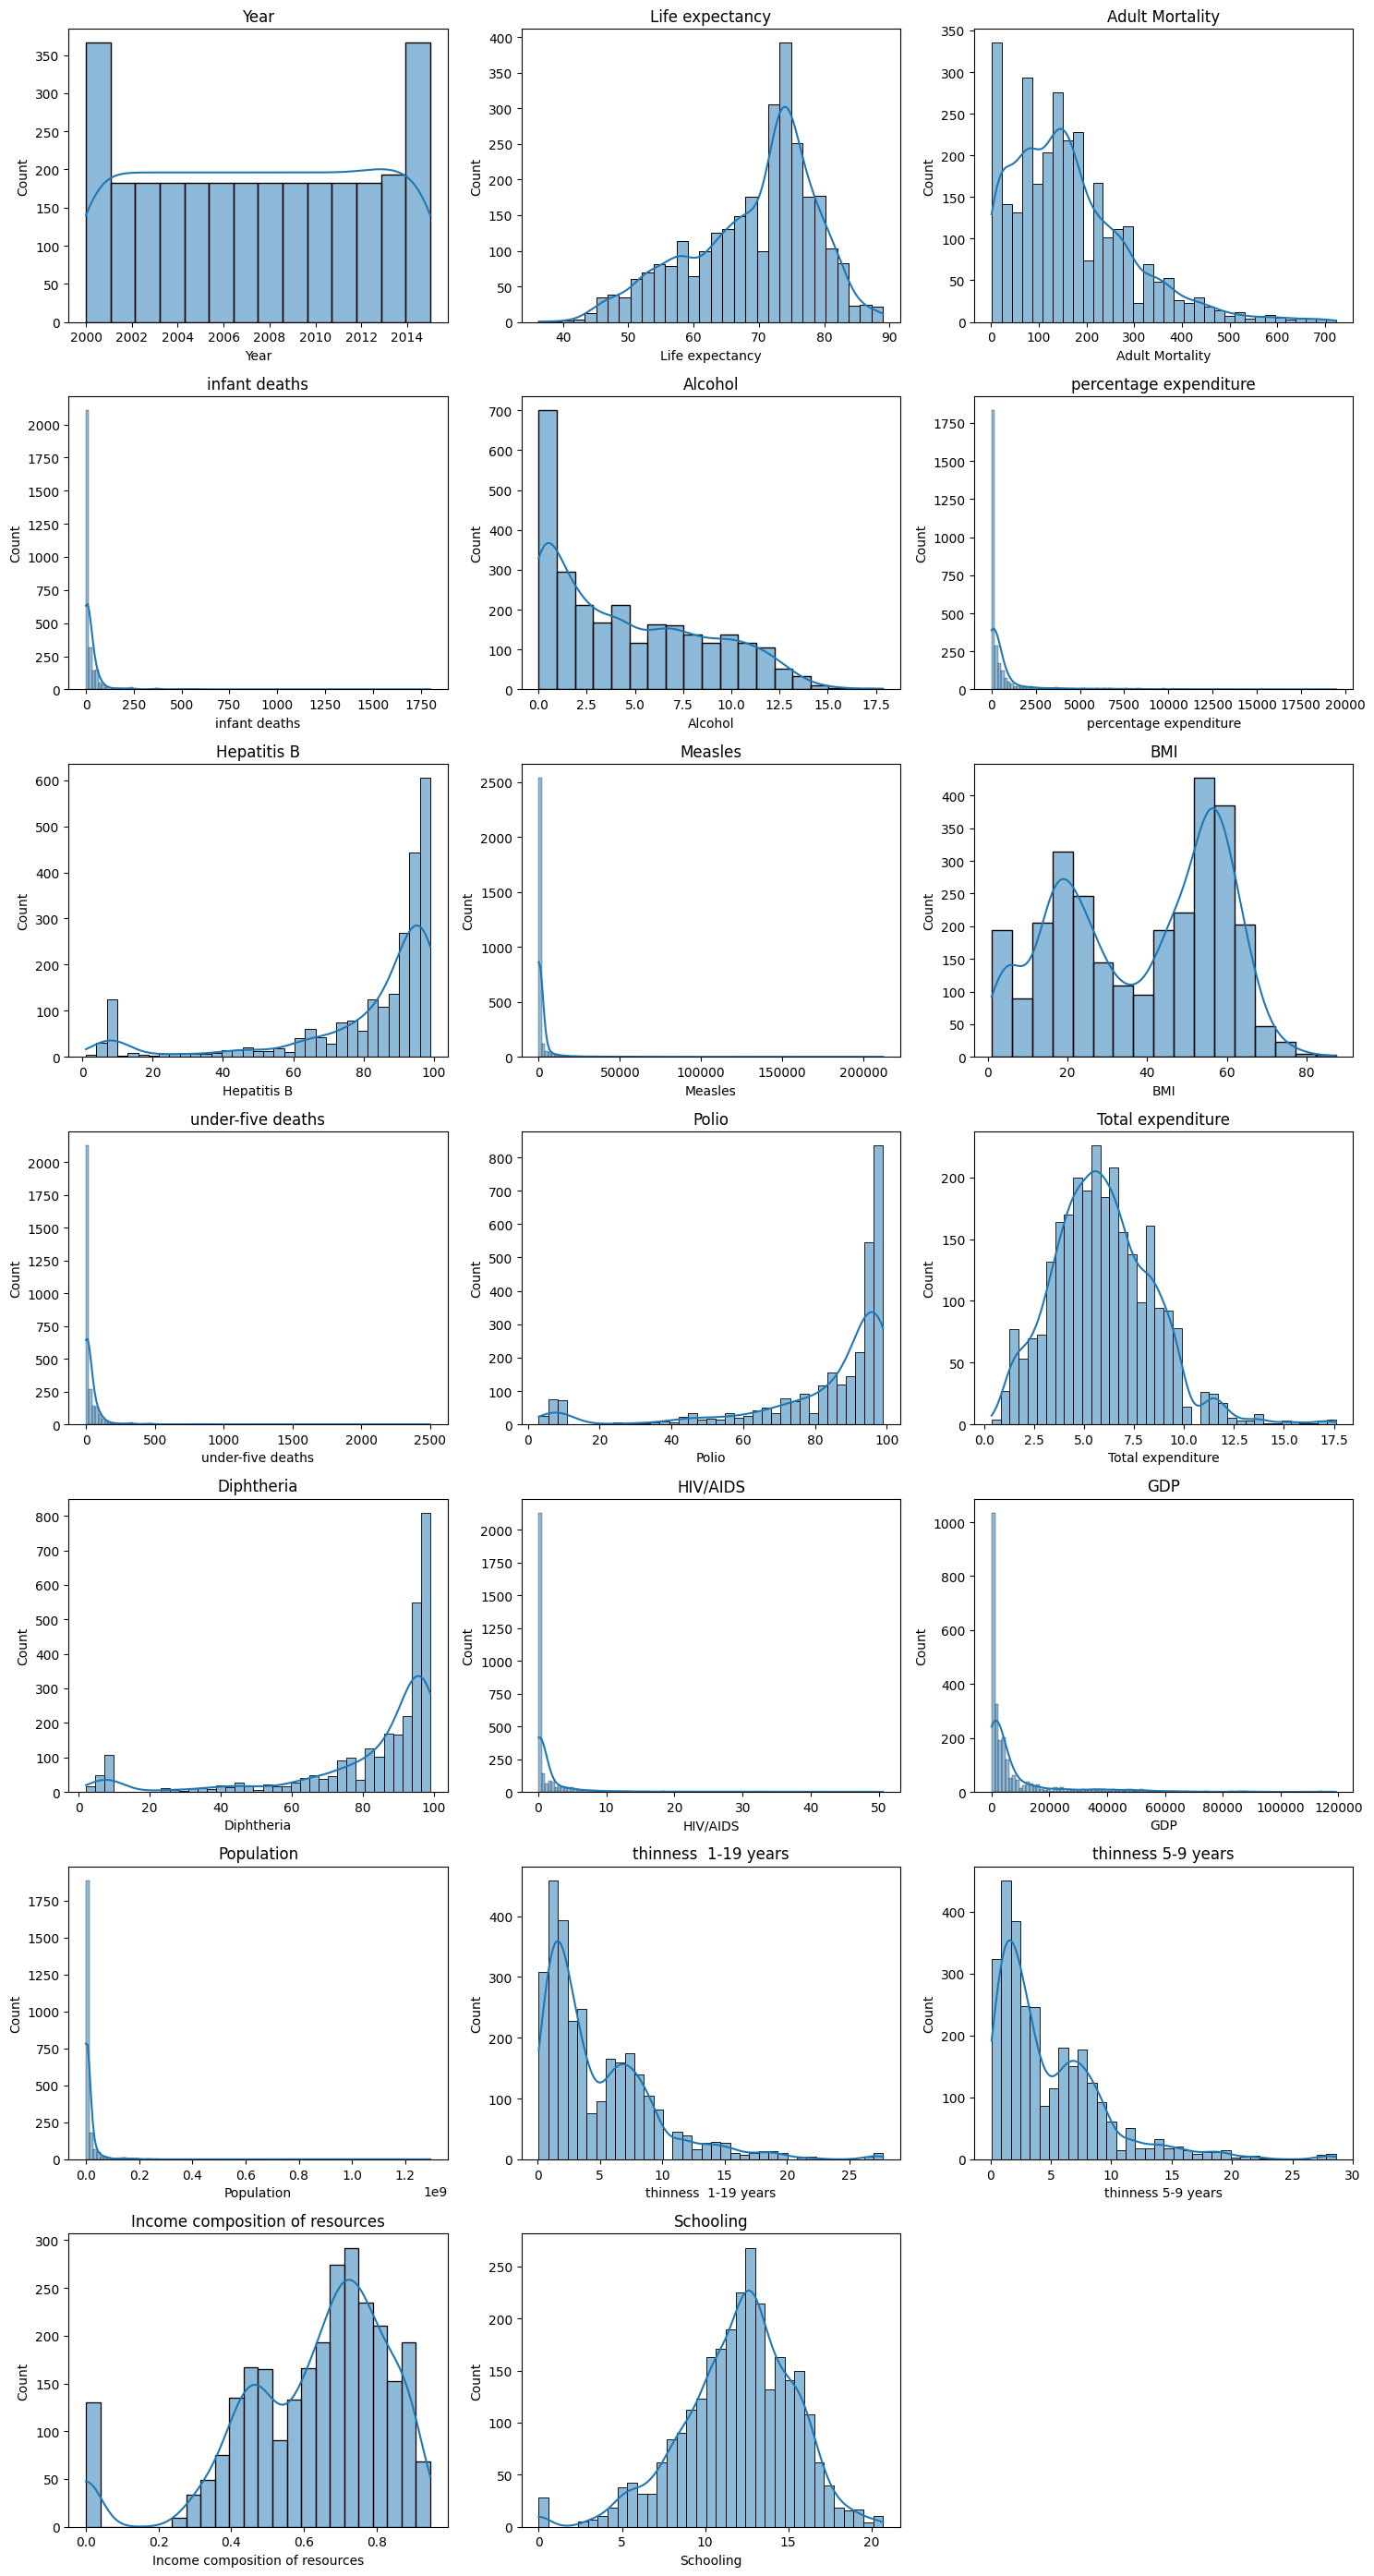

In [11]:
plot_grid(df, num_cols, sns.histplot, kde=True)

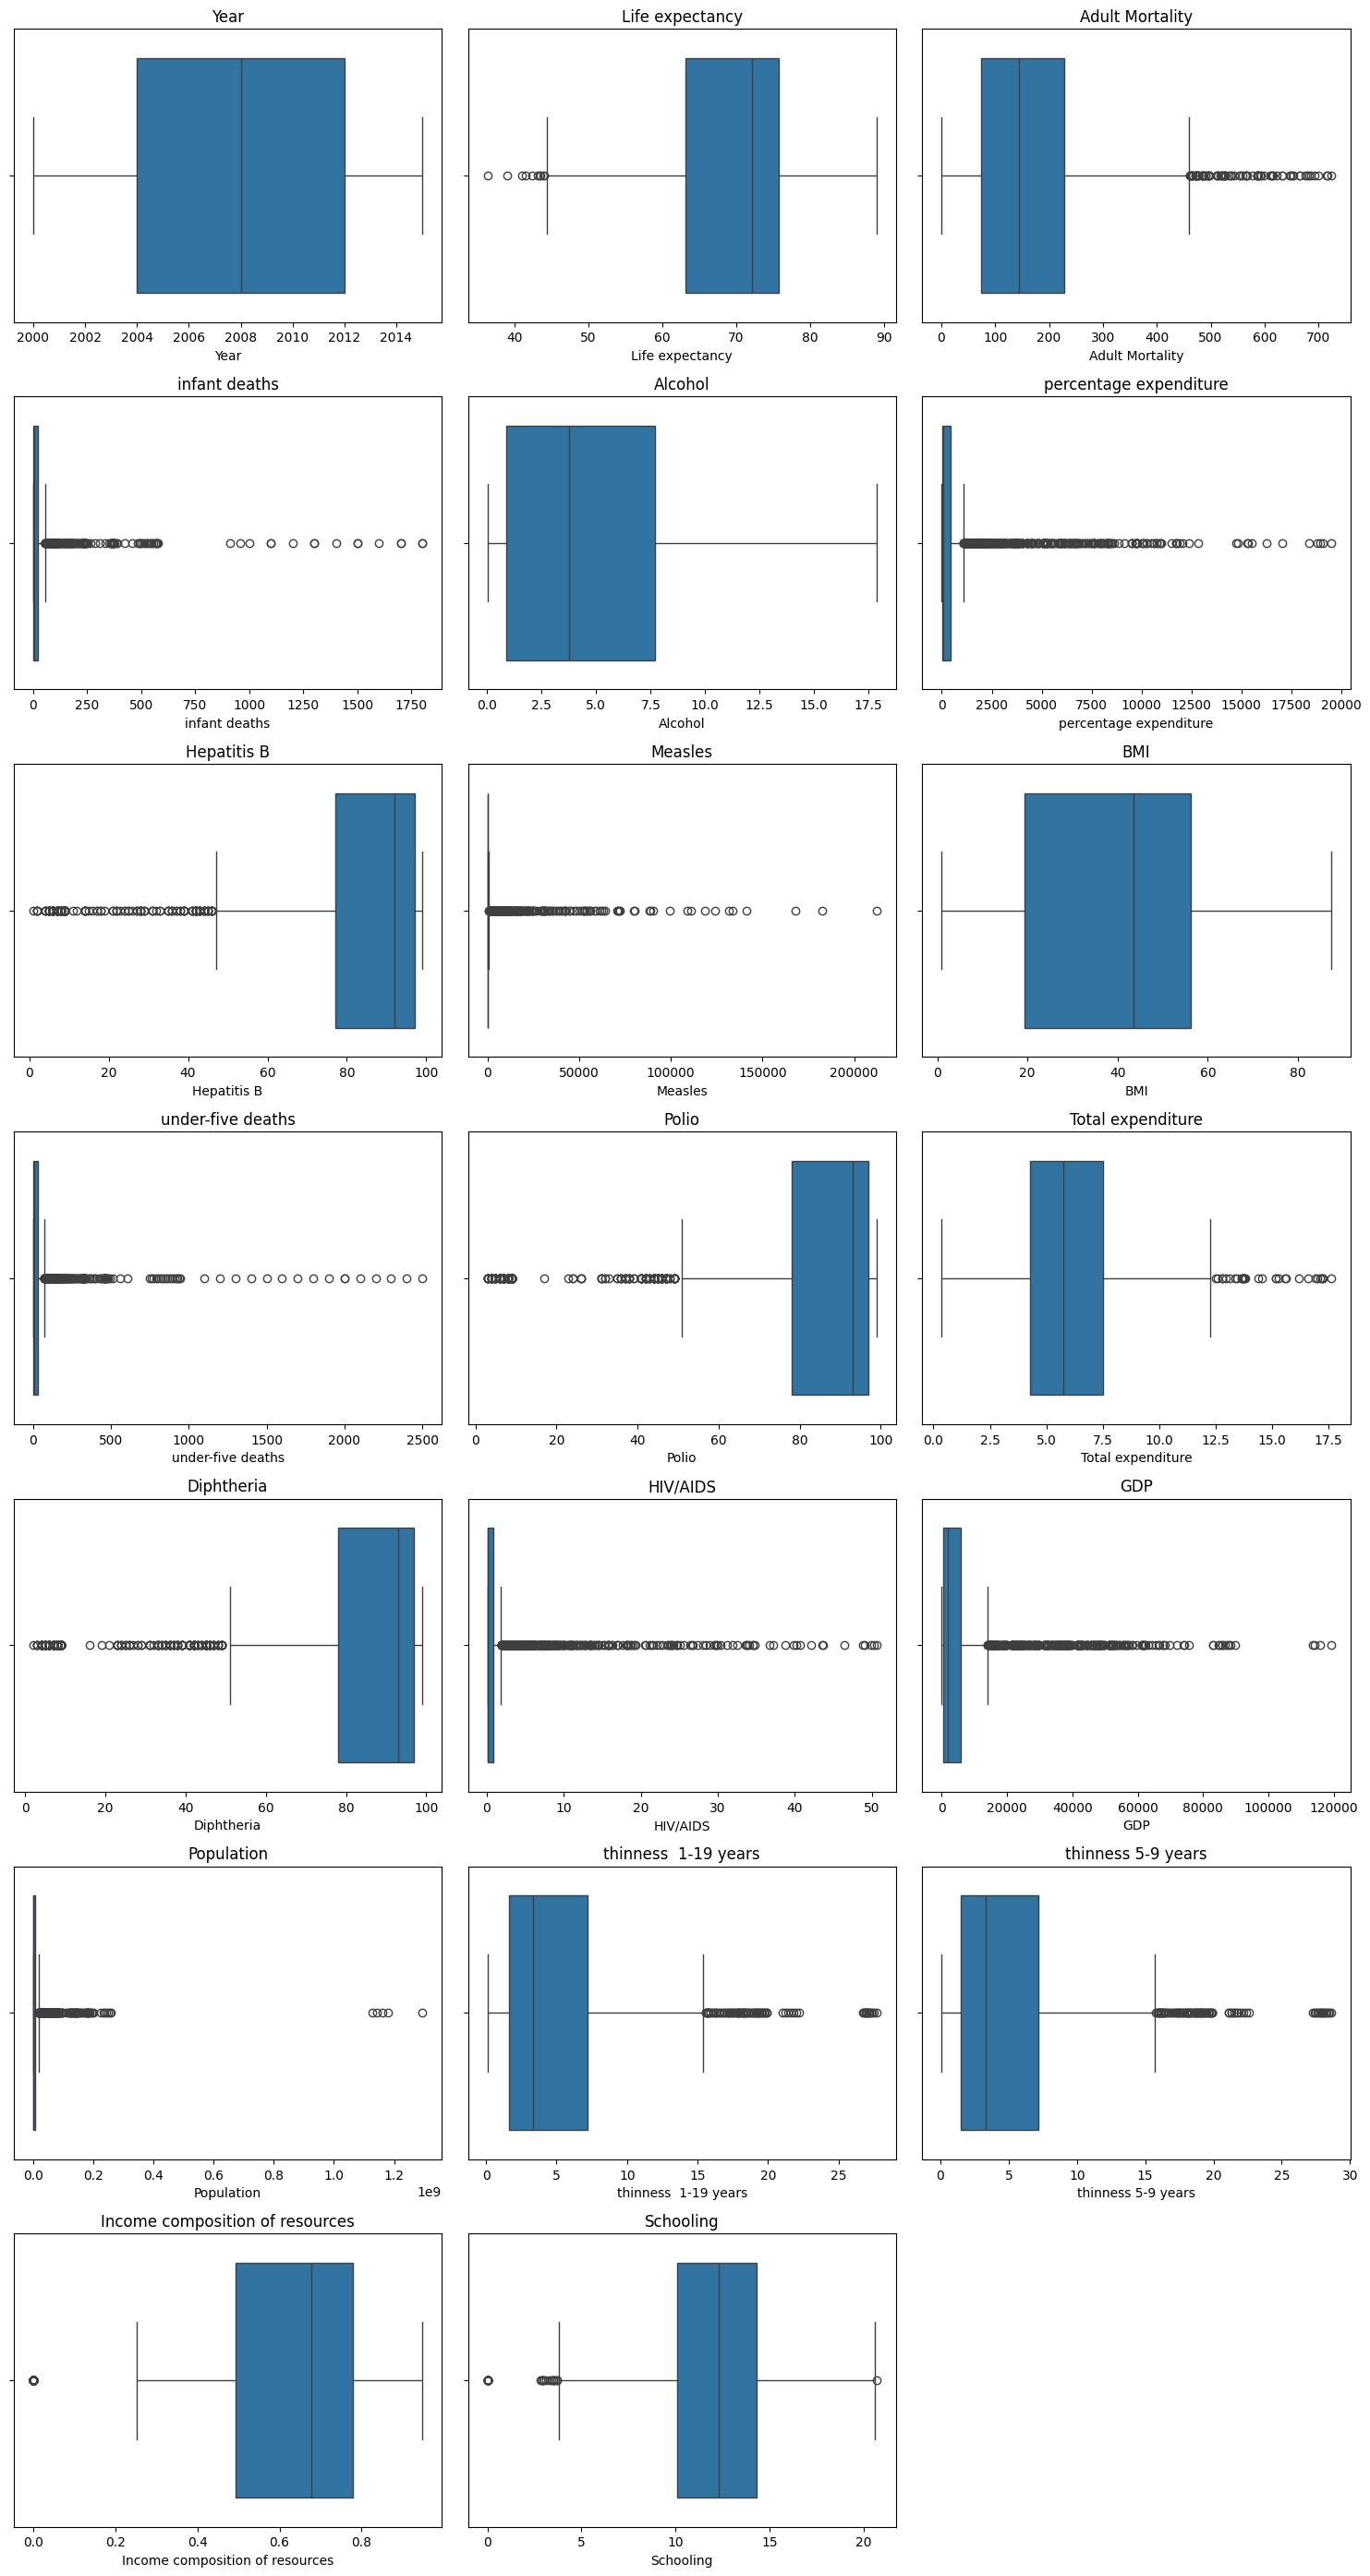

In [12]:
plot_grid(df, num_cols, sns.boxplot)

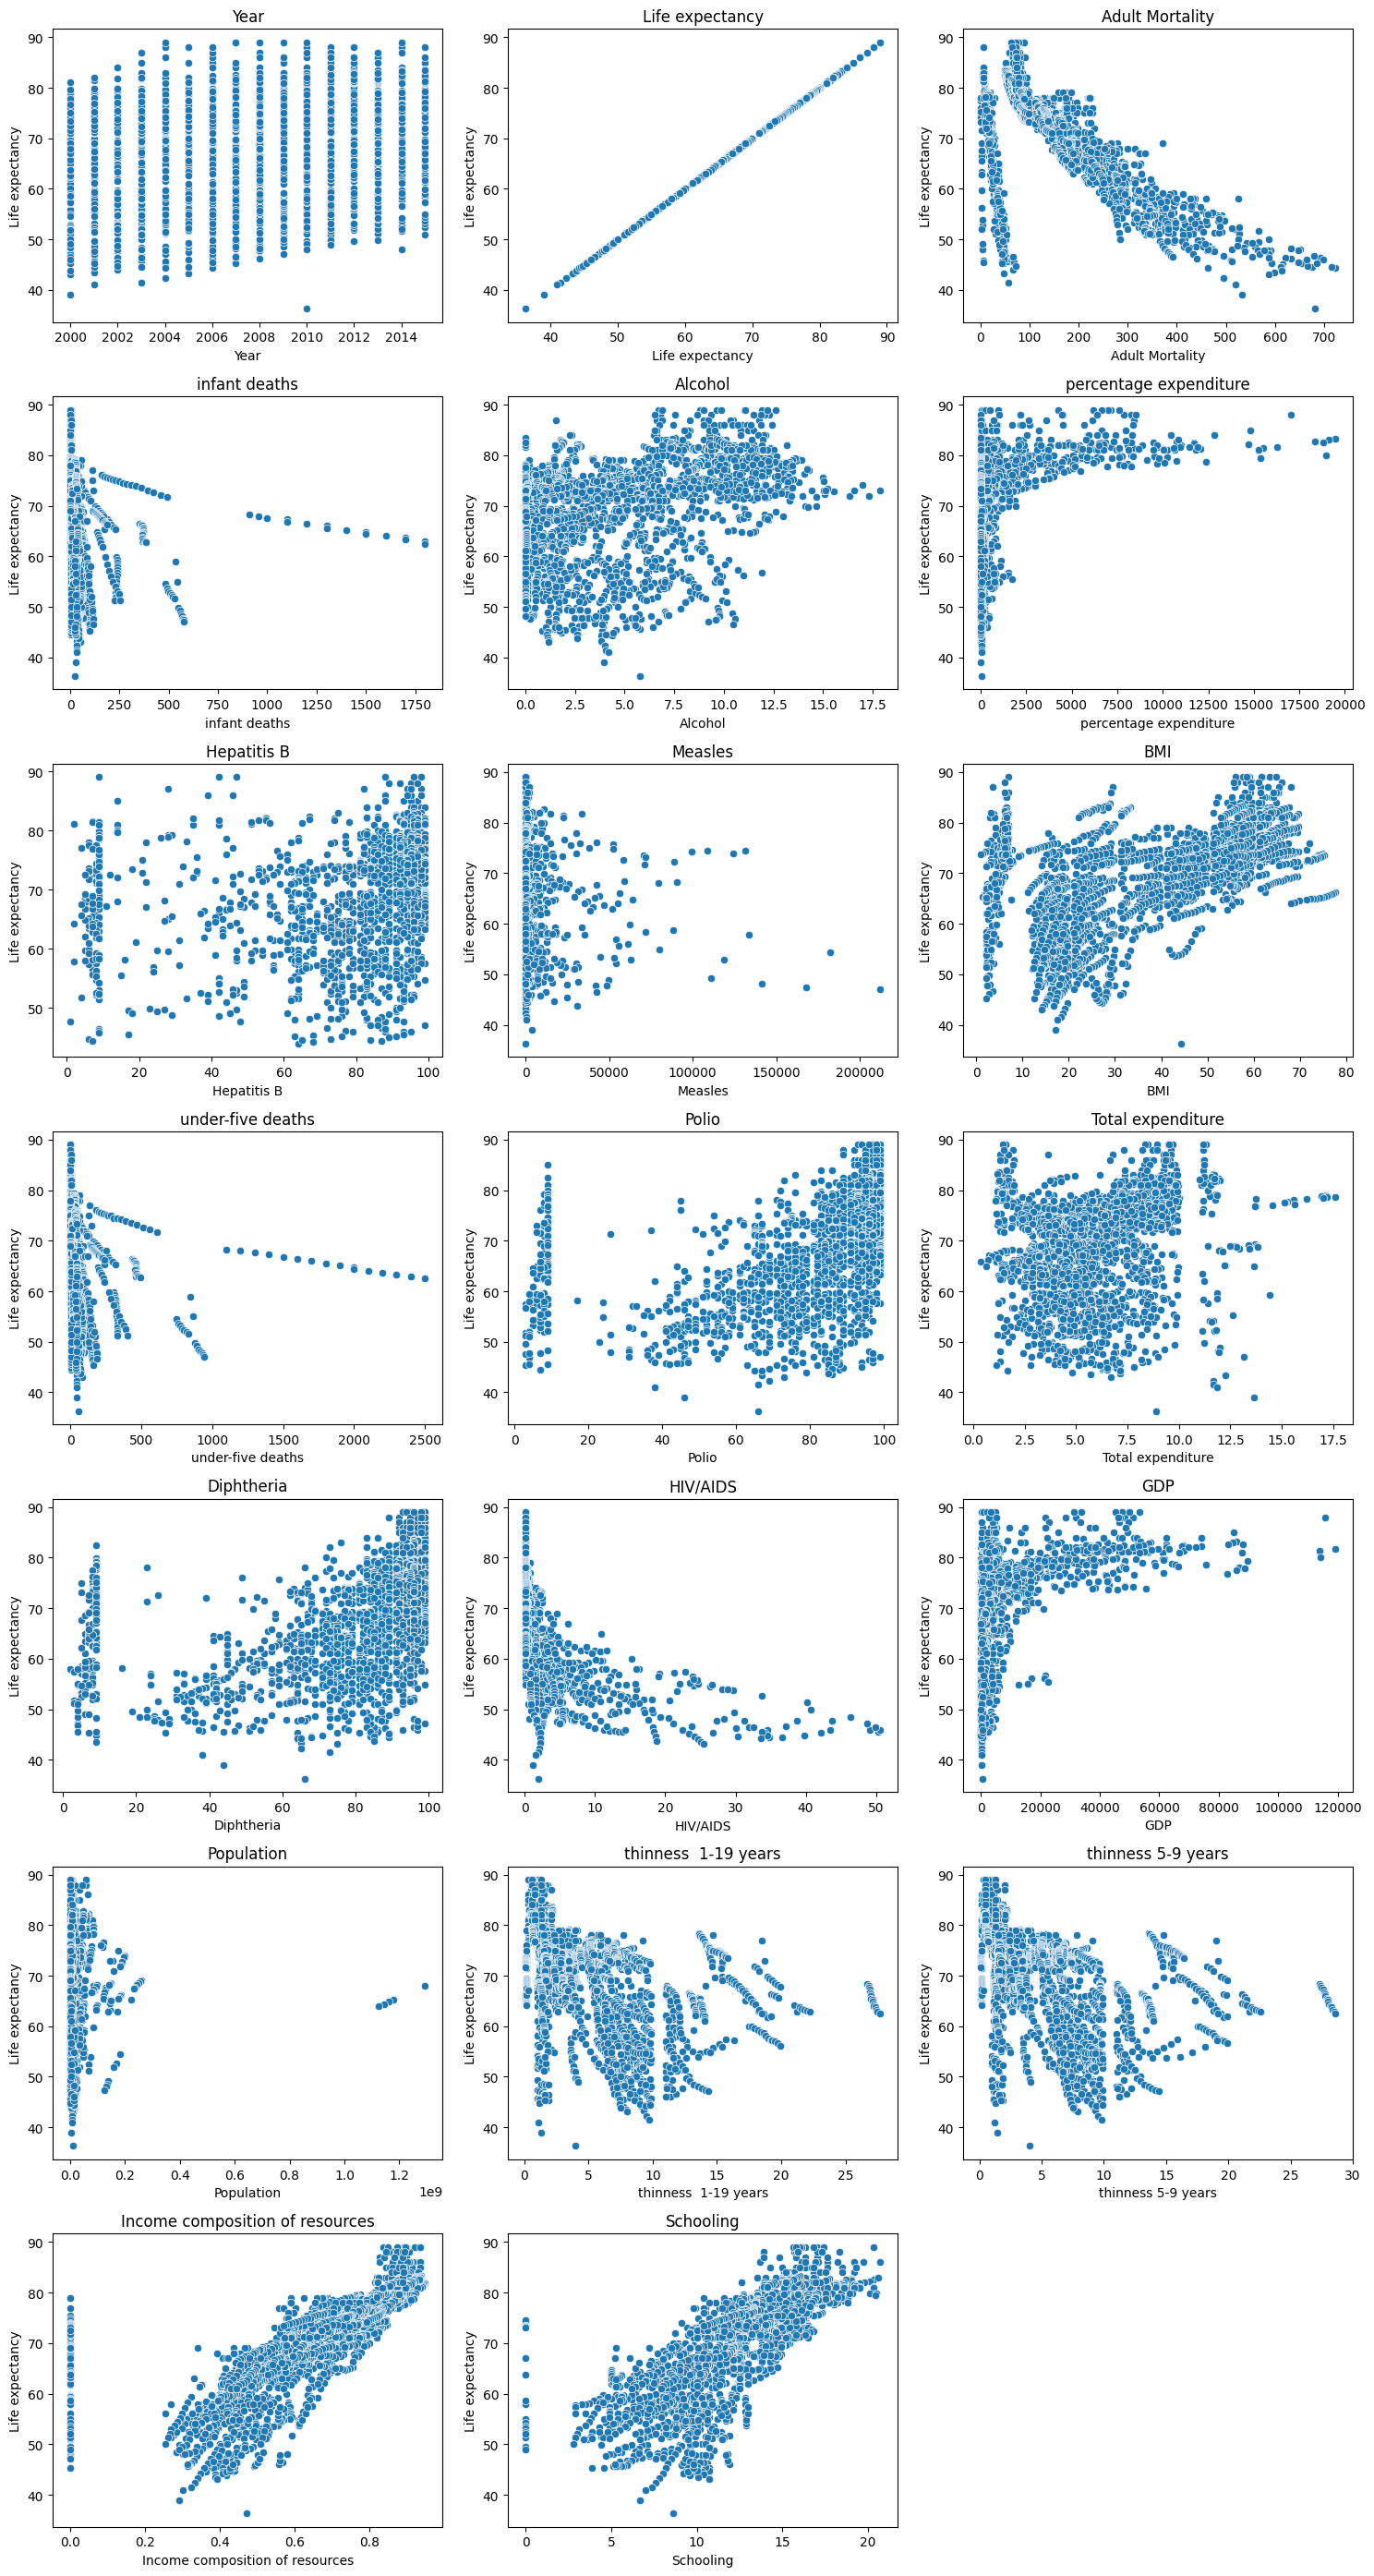

In [13]:
plot_grid(df, num_cols, sns.scatterplot, y='Life expectancy')

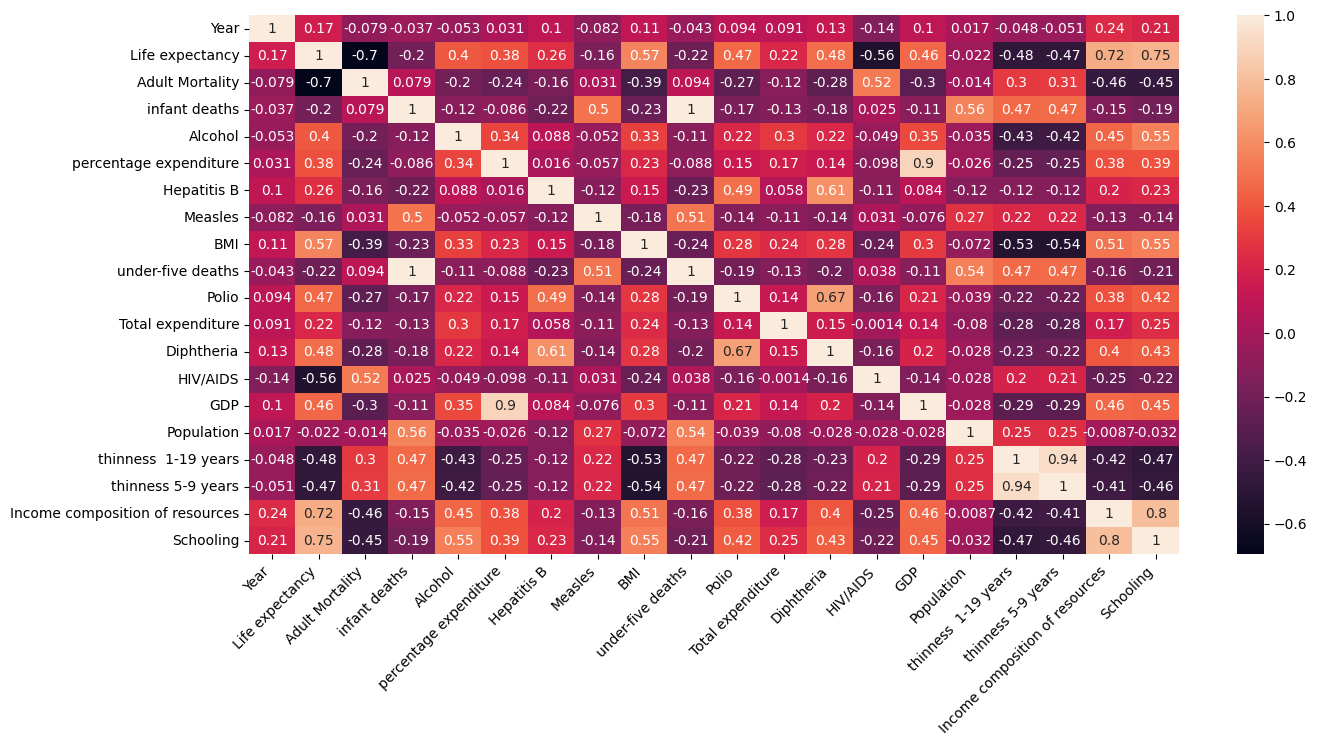

In [14]:
plt.figure(figsize=(15, 7))
plt.tight_layout()

sns.heatmap(df[num_cols].corr(), annot=True)

plt.xticks(rotation=45, ha="right")


plt.show()

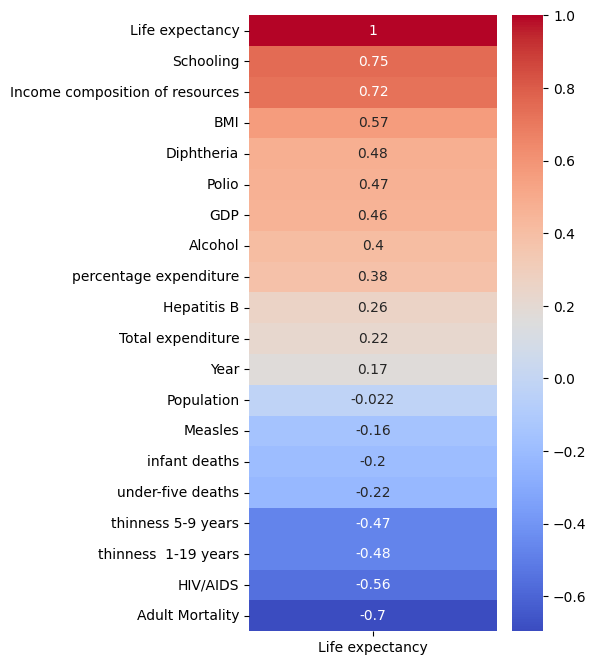

In [15]:
correlacao_alvo = (
    df[num_cols]
      .corr()[["Life expectancy"]]
      .sort_values("Life expectancy", ascending=False)
)
plt.figure(figsize=(4, 8))
sns.heatmap(correlacao_alvo, annot=True, cmap='coolwarm')
plt.show()


In [16]:
# pip install plotly
# pip install nbformat

import plotly.express as px


for col in txt_cols:
    df_counts = df[col].value_counts().reset_index()
    df_counts.columns = [col, 'contagem'] # Nomeamos as colunas para o Plotly entender
    
    fig = px.treemap(
        df_counts, 
        path=[col],            # A categoria
        values='contagem',     # A quantidade de vezes que ela aparece
        title=f'Distribuição de Frequência: {col}',
        color='contagem',      # Cor variando pela quantidade
        color_continuous_scale='Ice'
    )

    fig.update_traces(textinfo="label+value+percent root")
    fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
    
    fig.show()

## Outlier tretment

 ## Data processing pipeline


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, FunctionTransformer
)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
import numpy as np

In [18]:
# Não imputar a label
df = df.dropna(subset=["Life expectancy"])

In [19]:
# Instanciação de transformadores

# Cada valor é uma FUNÇÃO que retorna uma instância nova (evita reuso de estado)
IMPUTERS = {
    # SimpleImputer — estratégias básicas
    'mean':           lambda: SimpleImputer(strategy='mean'),
    'median':         lambda: SimpleImputer(strategy='median'),
    'most_frequent':  lambda: SimpleImputer(strategy='most_frequent'),
    'constant_0':     lambda: SimpleImputer(strategy='constant', fill_value=0),
    'constant_missing': lambda: SimpleImputer(strategy='constant', fill_value='missing'),

    # KNNImputer — usa vizinhos mais próximos
    'knn_3':          lambda: KNNImputer(n_neighbors=3),
    'knn_5':          lambda: KNNImputer(n_neighbors=5),
    'knn_10':         lambda: KNNImputer(n_neighbors=10),

    # IterativeImputer — modela cada feature como função das outras (MICE)
    'iterative':      lambda: IterativeImputer(random_state=42),
    'iterative_10':   lambda: IterativeImputer(max_iter=10, random_state=42),
}

TRANSFORMS = {
    'log1p':  lambda: FunctionTransformer(np.log1p, validate=True),
    'log10':  lambda: FunctionTransformer(
                  lambda x: np.log10(np.clip(x, 1e-9, None)), validate=True),
    'sqrt':   lambda: FunctionTransformer(
                  lambda x: np.sqrt(np.clip(x, 0, None)), validate=True),
    'square': lambda: FunctionTransformer(np.square, validate=True),
    None:     lambda: None,
}

SCALERS = {
    'standard': lambda: StandardScaler(),
    'minmax':   lambda: MinMaxScaler(),
    'robust':   lambda: RobustScaler(),
    None:       lambda: None,
}

COLUMN_CONFIG = {
    # KNN para colunas com missing não-aleatório
    'Renda':       dict(imputer='knn_5',        transform='log1p',  scaler='standard'),
    'Valor_Venda': dict(imputer='knn_5',        transform='log1p',  scaler='standard'),

    # Iterative para colunas correlacionadas
    'Contagem':    dict(imputer='iterative',    transform='sqrt',   scaler='minmax'),
    'Visitas':     dict(imputer='iterative',    transform='sqrt',   scaler='minmax'),

    # Simples para colunas sem padrão complexo de missing
    'Idade':       dict(imputer='mean',         transform=None,     scaler='standard'),
    'BMI':         dict(imputer='median',       transform=None,     scaler='robust'),

    # Categóricas
    'Status':      dict(imputer='most_frequent', encoder='onehot'),
    'Regiao':      dict(imputer='most_frequent', encoder='onehot'),
    'Grau_Risco':  dict(imputer='constant_missing', encoder='ordinal',
                        categories=[['baixo', 'medio', 'alto']]),
}

In [20]:
# ─── Configuração declarativa por coluna ──────────────────────────────────
COLUMN_CONFIG = {
    # Numéricas com missing baixo - imputação simples
    'Year':                          dict(imputer='median',         transform=None,     scaler=None),
    'Adult Mortality':               dict(imputer='median',         transform=None,     scaler=None),
    'infant deaths':                 dict(imputer='median',         transform=None,     scaler=None),
    'Alcohol':                       dict(imputer='median',         transform=None,     scaler=None),
    'Hepatitis B':                   dict(imputer='median',         transform=None,     scaler=None),
    'Measles':                       dict(imputer='median',         transform=None,     scaler=None),
    'BMI':                           dict(imputer='median',         transform=None,     scaler=None),
    'under-five deaths':             dict(imputer='median',         transform=None,     scaler=None),
    'Polio':                         dict(imputer='median',         transform=None,     scaler=None),
    'Total expenditure':             dict(imputer='median',         transform=None,     scaler=None),
    'Diphtheria':                    dict(imputer='median',         transform=None,     scaler=None),
    'HIV/AIDS':                      dict(imputer='median',         transform=None,     scaler=None),
    'thinness  1-19 years':          dict(imputer='median',         transform=None,     scaler=None),
    'thinness 5-9 years':            dict(imputer='median',         transform=None,     scaler=None),
    'Income composition of resources': dict(imputer='median',       transform=None,     scaler=None),
    'Schooling':                     dict(imputer='median',         transform=None,     scaler=None),

    # Numéricas com missing alto - KNN para capturar padrões
    'percentage expenditure':        dict(imputer='knn_5',          transform='log1p',  scaler=None),
    'GDP':                           dict(imputer='knn_5',          transform='log1p',  scaler=None),
    'Population':                    dict(imputer='knn_5',          transform='log1p',  scaler=None),

    # Categórica
    'Status':                        dict(imputer='most_frequent',  encoder='ordinal', categories=[['Developing', 'Developed']]),
}

In [21]:
# ─── Builder do pipeline por coluna ───────────────────────────────────────
def build_column_pipeline(cfg: dict) -> Pipeline:
    steps = []

    imputer_key = cfg.get('imputer', 'median')
    if imputer_key not in IMPUTERS:
        raise ValueError(
            f"Imputer '{imputer_key}' não encontrado. "
            f"Disponíveis: {list(IMPUTERS)}"
        )
    steps.append(('imputer', IMPUTERS[imputer_key]()))

    transform = TRANSFORMS.get(cfg.get('transform'), lambda: None)()
    if transform is not None:
        steps.append(('transform', transform))

    scaler = SCALERS.get(cfg.get('scaler'), lambda: None)()
    if scaler is not None:
        steps.append(('scaler', scaler))

    encoder_type = cfg.get('encoder')
    if encoder_type == 'onehot':
        steps.append(('encoder', OneHotEncoder(
            handle_unknown='ignore', sparse_output=False)))
    elif encoder_type == 'ordinal':
        cats = cfg.get('categories', 'auto')
        steps.append(('encoder', OrdinalEncoder(categories=cats)))

    return Pipeline(steps)

# ─── Builder do ColumnTransformer ─────────────────────────────────────────
def build_preprocessor(config: dict) -> ColumnTransformer:
    transformers = [
        (
            f"{cfg.get('encoder', cfg.get('transform', 'num'))}_{col}",
            build_column_pipeline(cfg),
            [col]
        )
        for col, cfg in config.items()
    ]
    return ColumnTransformer(transformers=transformers, remainder='drop')

## Model Training

In [22]:
from sklearn.ensemble import RandomForestRegressor

preprocessor = build_preprocessor(COLUMN_CONFIG)
pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor()),
])

In [23]:
from sklearn.model_selection import GridSearchCV, KFold

# Preparar dados
X = df.drop('Life expectancy', axis=1)
y = df['Life expectancy']

# Parâmetros para tunagem
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]
}


cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipeline_final,
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

## Model results

In [24]:
print("Melhores parâmetros:", grid.best_params_)
print("Melhor score (MSE negativo):", grid.best_score_)
print("MSE médio:", -grid.best_score_)

Melhores parâmetros: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Melhor score (MSE negativo): -3.2841773261599676
MSE médio: 3.2841773261599676


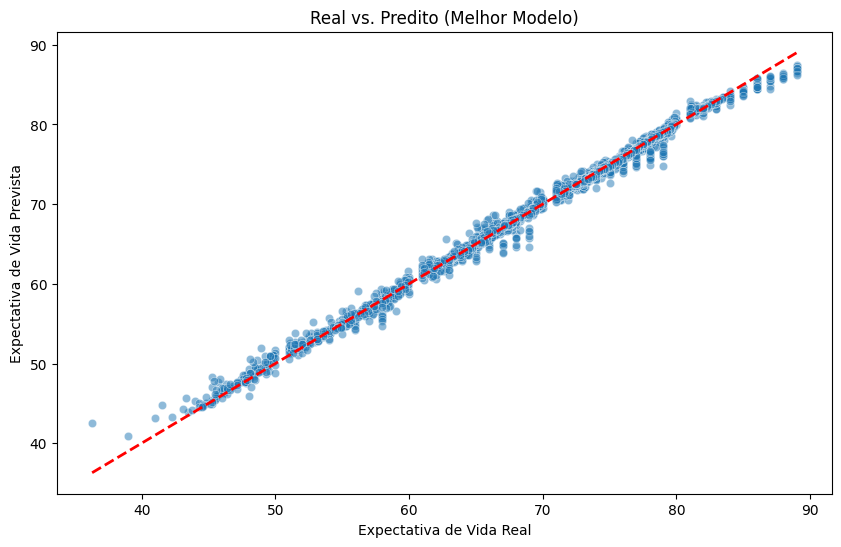

In [25]:
# Usar o melhor modelo do GridSearch para prever
y_pred = grid.predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2) # Linha de perfeição
plt.xlabel('Expectativa de Vida Real')
plt.ylabel('Expectativa de Vida Prevista')
plt.title('Real vs. Predito (Melhor Modelo)')
plt.show()

In [26]:
#pip install statsmodels

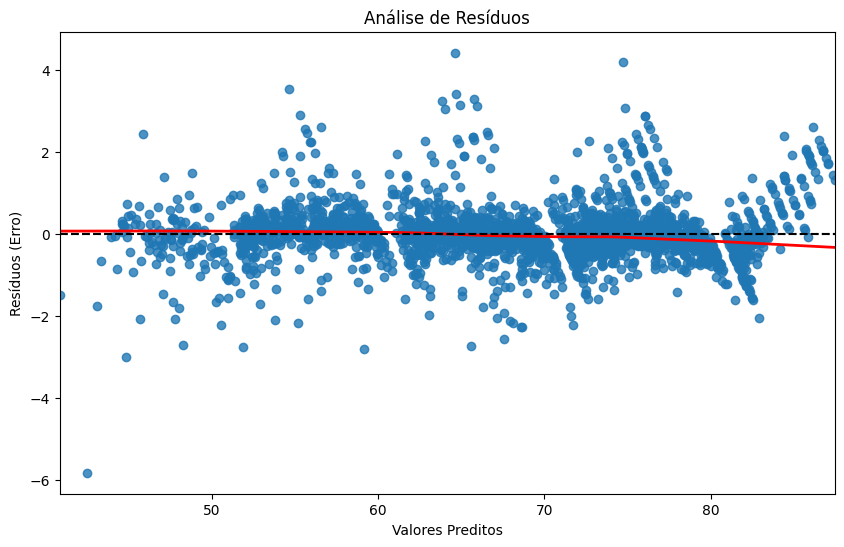

In [27]:
residuos = y - y_pred

plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuos, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos (Erro)')
plt.title('Análise de Resíduos')
plt.show()

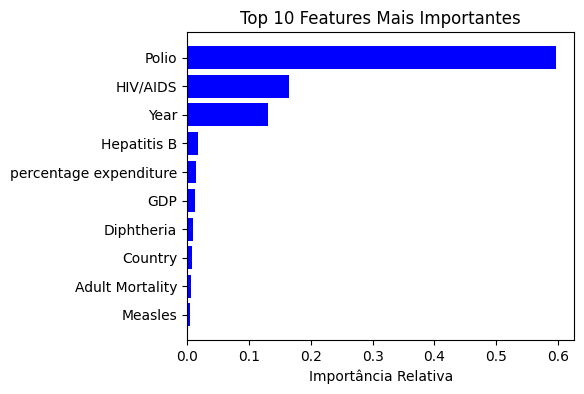

In [30]:
# Extrair o modelo final do pipeline vencedor
best_model = grid.best_estimator_.named_steps['model']

# Pegar os nomes das colunas após o pré-processamento (importante!)
# Se usou OneHotEncoder, os nomes mudam, mas para um teste rápido:
features = X.columns # Se não houver OneHot, isso funciona direto

importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(5, 4))
plt.title('Top 10 Features Mais Importantes')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importância Relativa')
plt.show()

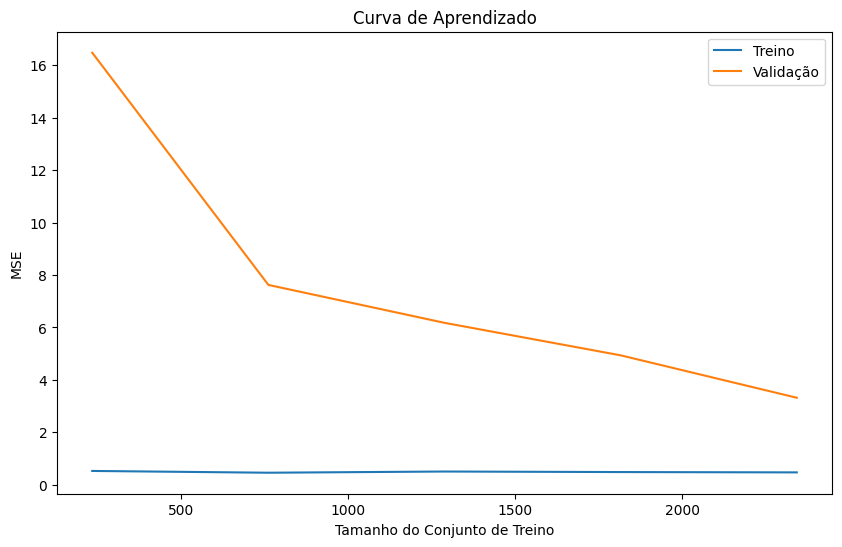

In [29]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    grid.best_estimator_, X, y, cv=cv, scoring='neg_mean_squared_error'
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, -train_scores.mean(axis=1), label='Treino')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Validação')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('MSE')
plt.title('Curva de Aprendizado')
plt.legend()
plt.show()